In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Display settings for pandas and seaborn
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
%%time
# due to memory issues, the code cell that dropped redunant columns is now incorporated into this step
# however instead of dropping them, the dataset just won't load them in instead to save memory space
mixed_columns = {
    'verification_status_joint': 'object', 
    'sec_app_earliest_cr_line': 'object'
}
# 1 identifiers & noise (useless for prediction)
id_columns = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'policy_code',
    'emp_title'
]
# 2. FUTURE LEAKAGE (The "Time Travel" Columns)
# These events happen AFTER the loan is issued. The bank cannot know these at origination.
leakage_columns = [
    'pymnt_plan',                                 # Payment plan status updates
    'out_prncp', 'out_prncp_inv',                 # Remaining debt (implies loan is active/defaulted)
    'total_pymnt', 'total_pymnt_inv',             # Total money received (The biggest cheat!)
    'total_rec_prncp', 'total_rec_int',           # Principal/Interest breakdown
    'total_rec_late_fee',                         # Late fees paid (implies they were late)
    'recoveries', 'collection_recovery_fee',      # Money recovered after default
    'last_pymnt_d', 'last_pymnt_amnt',            # Date/Amount of last payment
    'next_pymnt_d',                               # Date of next payment
    'last_credit_pull_d',                         # Date the bank last checked their credit (ongoing)
    
    # CRITICAL: 'last_fico' is the CURRENT score. 'fico_range' is the ORIGINATION score.
    'last_fico_range_high', 'last_fico_range_low', 

    # Hardship & Settlement (Only exists if they struggled later)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accured_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term'
]
drop_cols = id_columns + leakage_columns
file_path = "../Data/accepted_2007_to_2018Q4.csv.gz"
all_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
# exclude the drop_cols...
keep_cols = [c for c in all_cols if c not in drop_cols]
# load dataset with drop_cols
df_accepted = pd.read_csv(
    file_path,
    usecols=keep_cols,
    dtype=mixed_columns
)
print(f"Final Implementation: {type(df_accepted)}")
print(f"Memory Usage: {df_accepted.memory_usage(deep=True).sum() / 1e9 :.2f} GB")

Final Implementation: <class 'pandas.DataFrame'>
Memory Usage: 3.80 GB
CPU times: total: 29.6 s
Wall time: 30.5 s


In [4]:
df_accepted.head()


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,orig_projected_additional_accrued_interest,disbursement_method
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,NaN,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.0,NaN,Joint App,71000.0,13.85,Not Verified,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,NaN,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,NaN,NaN,13.0,0.0,7802.0,11.6,17.0,w,0.0,NaN,Individual,NaN,NaN,NaN,0.0,0.0,301500.0,1.0,1.0,0.0,1.0,23.0,12609.0,70.0,1.0,1.0,6987.0,45.0,67300.0,0.0,1.0,0.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
df_accepted.shape

(2260701, 106)

In [6]:
df_accepted.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 106 entries, loan_amnt to disbursement_method
dtypes: float64(90), object(2), str(14)
memory usage: 1.8+ GB


In [7]:
df_accepted.isna().sum()

loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
term                                               33
int_rate                                           33
                                               ...   
sec_app_chargeoff_within_12_mths              2152680
sec_app_collections_12_mths_ex_med            2152680
sec_app_mths_since_last_major_derog           2224759
orig_projected_additional_accrued_interest    2252050
disbursement_method                                33
Length: 106, dtype: int64

In [8]:
df_accepted['loan_status']

0           Fully Paid
1           Fully Paid
2           Fully Paid
3              Current
4           Fully Paid
              ...     
2260696        Current
2260697    Charged Off
2260698        Current
2260699            NaN
2260700            NaN
Name: loan_status, Length: 2260701, dtype: str

In [9]:
# Filter rows, keep only finish loans
df_accepted = df_accepted[df_accepted['loan_status'].isin(['Fully Paid', 'Charged Off'])]
# Make it binary, 1 = Default (Charged Off), 0 = Good (Fully Paid)
mapping = {'Charged Off':1, 'Fully Paid':0}
df_accepted['loan_status'] = df_accepted['loan_status'].map(mapping)
# Verify
print(f"New Shape: {df_accepted.shape}")
print(df_accepted['loan_status'].value_counts())

New Shape: (1345310, 106)
loan_status
0    1076751
1     268559
Name: count, dtype: int64


In [10]:
# issue dates
df_accepted['issue_d'] = pd.to_datetime(
    df_accepted['issue_d'], format = "%b-%Y")
assert df_accepted['issue_d'].isna().sum() == 0
issue_dates = df_accepted['issue_d'].copy()
df_accepted = df_accepted.drop(columns='issue_d', errors='ignore')
print(issue_dates.min(), issue_dates.max(), len(issue_dates), len(df_accepted))

2007-06-01 00:00:00 2018-12-01 00:00:00 1345310 1345310


C:\Users\henry\AppData\Local\Temp\ipykernel_51612\572253095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df_accepted, palette='viridis')


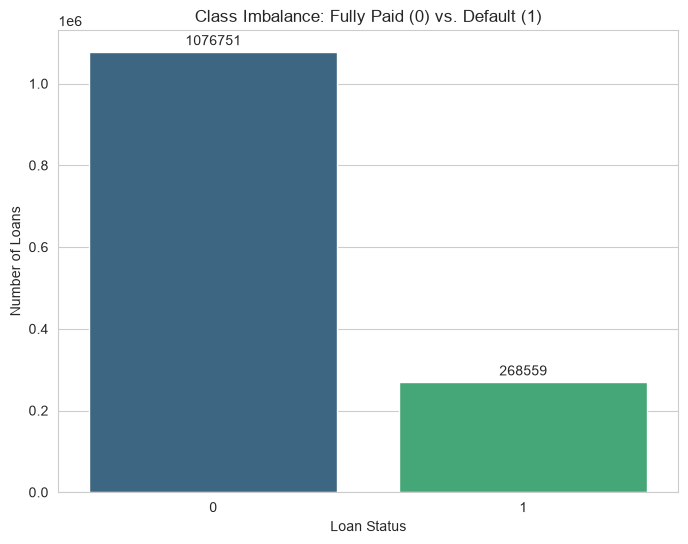

Visual saved successfully as class_imbalance.png


In [11]:
# The target balance (Countplot)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='loan_status', data=df_accepted, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
    plt.title('Class Imbalance: Fully Paid (0) vs. Default (1)')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.show()

print("Visual saved successfully as class_imbalance.png")

C:\Users\henry\AppData\Local\Temp\ipykernel_51612\2857476234.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.head(50).values, y=missing_data.head(50).index, palette='viridis')


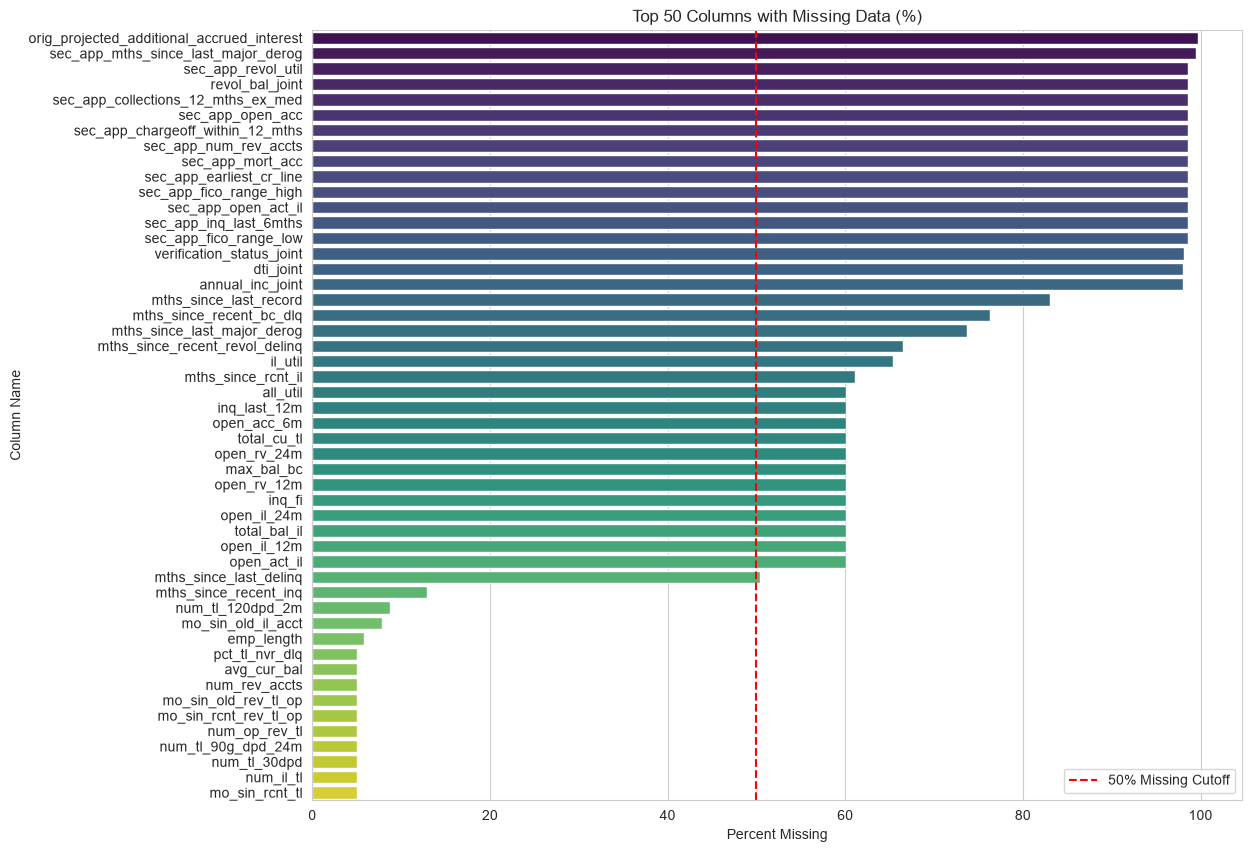

In [12]:
# calculate the % of missing data for each column
missing_fractions = df_accepted.isnull().mean().sort_values(ascending=False)*100
# filter to show only columns that strictly have missing data
missing_data = missing_fractions[missing_fractions > 0]
# Plot the top 50 missing columns
plt.figure(figsize=(12,10))
sns.barplot(x=missing_data.head(50).values, y=missing_data.head(50).index, palette='viridis')
# redline at 50% to signal cutoff for "junk columns"
plt.axvline(x=50, color='r', linestyle='--', label='50% Missing Cutoff')
plt.title('Top 50 Columns with Missing Data (%)')
plt.xlabel('Percent Missing')
plt.ylabel('Column Name')
plt.legend()
plt.show()

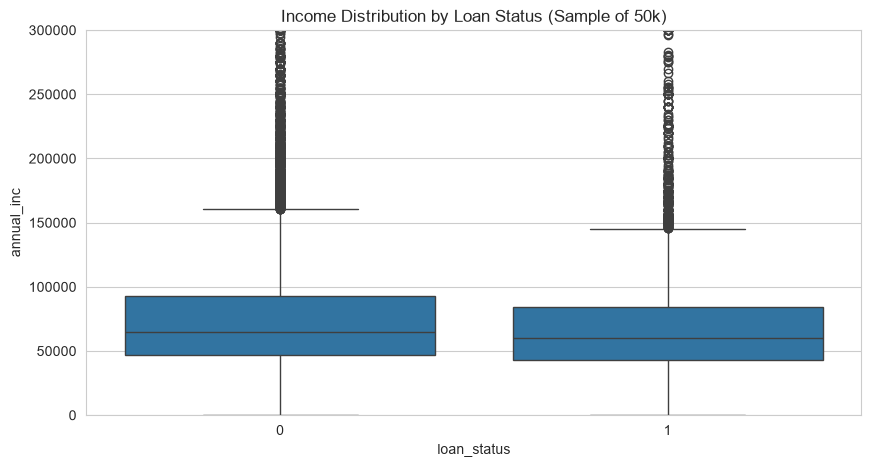

In [13]:
# Financial Outliers (Boxplot)
sampel_df = df_accepted.sample(n=50000, random_state=42)
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='annual_inc', data=sampel_df)
plt.ylim(0, 300000)
plt.title('Income Distribution by Loan Status (Sample of 50k)')
plt.show()

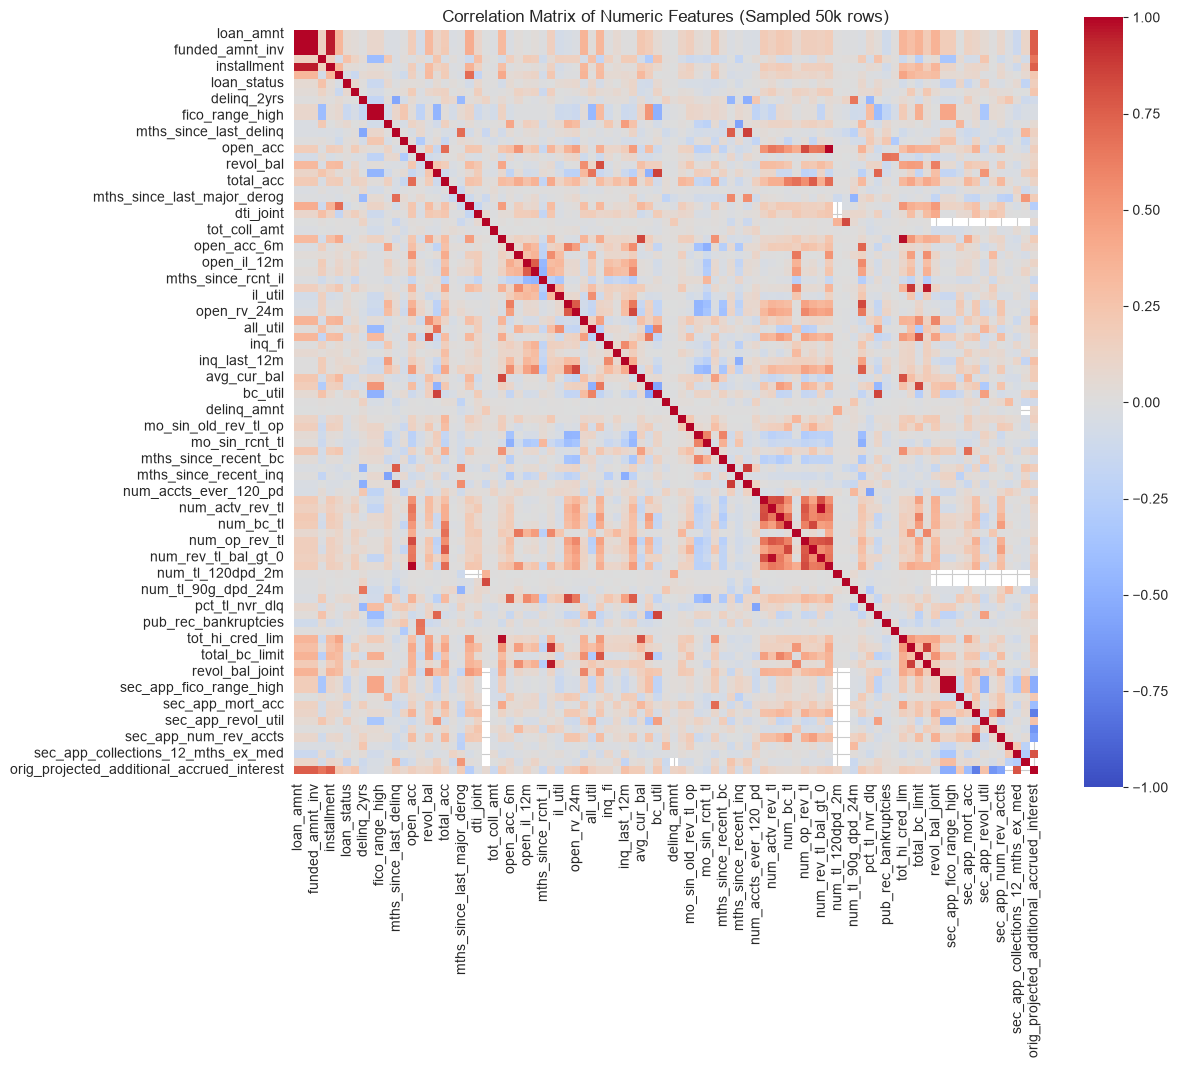

In [14]:
# The Correlation Matrix (Heatmap)
# Red/Hot = Strong + correlation, Blue/Cold = Strong - correlation
# select only numeric columns for correlation
numeric_df = df_accepted.select_dtypes(include=['float64', 'int64'])
numeric_sample = numeric_df.sample(n=50000, random_state=42)
corr_matrix = numeric_sample.corr()
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=False,
    square=True
)
plt.title('Correlation Matrix of Numeric Features (Sampled 50k rows)')
plt.show()

Statistics for non-empty rows
       mths_since_last_delinq  mths_since_last_record  \
count           666567.000000           228555.000000   
mean                34.312069               70.637120   
std                 21.919162               26.579224   
min                  0.000000                0.000000   
25%                 16.000000               53.000000   
50%                 31.000000               72.000000   
75%                 50.000000               90.000000   
max                226.000000              129.000000   

       mths_since_last_major_derog  mths_since_recent_bc_dlq  \
count                353750.000000             319020.000000   
mean                     43.701165                 39.652617   
std                      21.378476                 22.698164   
min                       0.000000                  0.000000   
25%                      27.000000                 21.000000   
50%                      44.000000                 38.000000   
75%     

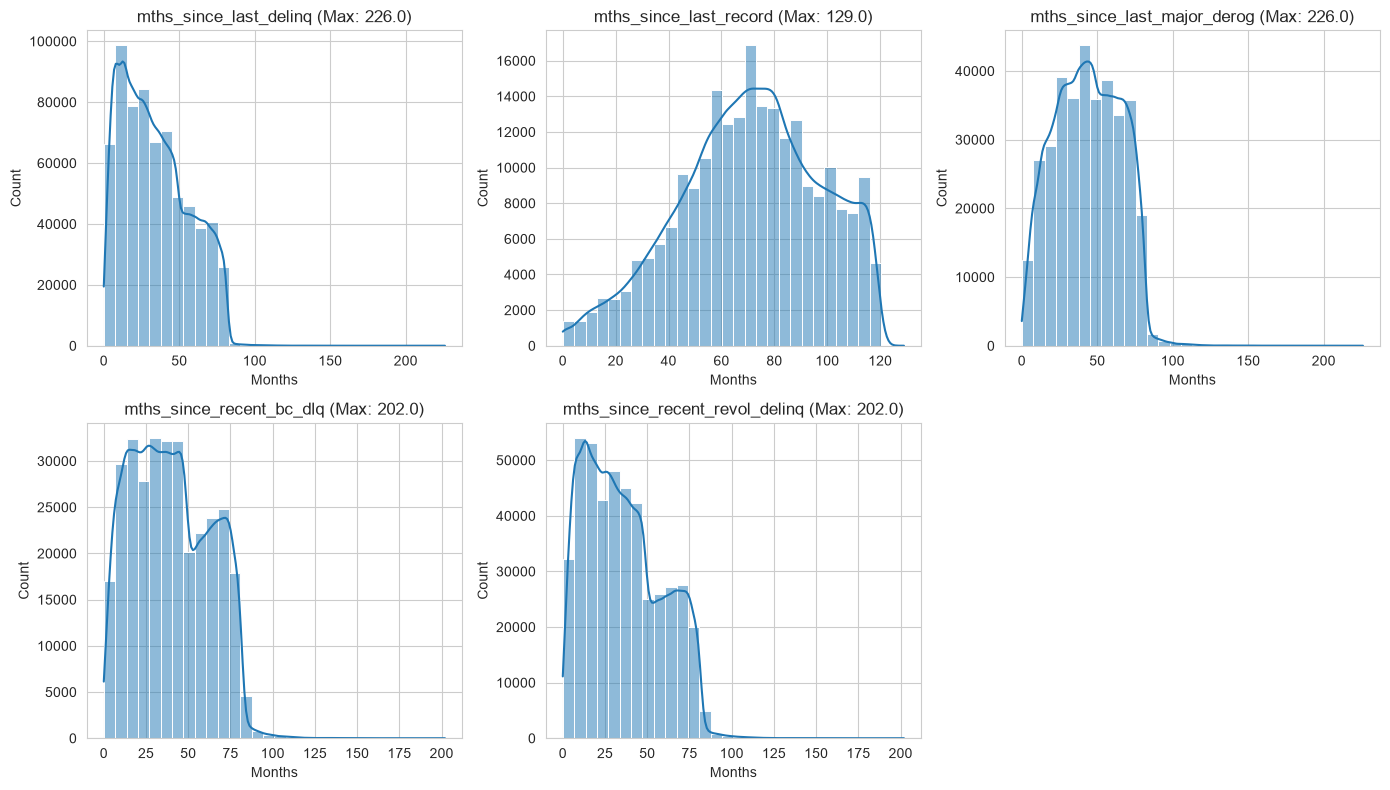

In [15]:
# save these columns since the absence of data is data
check_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq'
]
# Calculate statistics (Min, Max, Median) ignoring NaNs
print("Statistics for non-empty rows")
print(df_accepted[check_cols].describe())

# visualize the distributions
plt.figure(figsize=(14,8))
for i, col in enumerate(check_cols, 1):
    plt.subplot(2, 3, i)
    # drop NaNs just for plotting
    data = df_accepted[col].dropna()
    sns.histplot(data, bins=30, kde=True)
    plt.title(f"{col} (Max: {data.max()})")
    plt.xlabel('Months')

plt.tight_layout()
plt.show()

In [16]:
# Rescue the "Clean record" columns, use 1000 since it is significantly higher than max real value (226)
clean_record_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq'
]
# fill NaNs with 1000
for col in clean_record_cols:
    if col in df_accepted.columns:
        df_accepted[col] = df_accepted[col].fillna(1000)
        print(f"filled NaNs in {col} with 1000")

print("\nMissing values after rescue (Should be 0):")
print(df_accepted[clean_record_cols].isna().sum())

filled NaNs in mths_since_last_delinq with 1000
filled NaNs in mths_since_last_record with 1000
filled NaNs in mths_since_last_major_derog with 1000
filled NaNs in mths_since_recent_bc_dlq with 1000
filled NaNs in mths_since_recent_revol_delinq with 1000

Missing values after rescue (Should be 0):
mths_since_last_delinq            0
mths_since_last_record            0
mths_since_last_major_derog       0
mths_since_recent_bc_dlq          0
mths_since_recent_revol_delinq    0
dtype: int64


In [17]:
threshold = len(df_accepted) * 0.5
# Identify columns with more than 50% NaN and drop them
cols_to_drop = df_accepted.columns[df_accepted.isna().sum() > threshold]
print(f"dropping {len(cols_to_drop)} columsn: {list(cols_to_drop)}")
df_accepted = df_accepted.dropna(thresh=threshold, axis=1)
print(f"shape after dropping empty columns: {df_accepted.shape}")

dropping 31 columsn: ['annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'orig_projected_additional_accrued_interest']
shape after dropping empty columns: (1345310, 74)


In [18]:
# Imputation Step
# Fix the "zero" columns (where NaN = 0)
zero_fill_cols = ['revol_util', 'pub_rec_bankruptcies', 'tax_liens', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths']
for col in zero_fill_cols:
    if col in df_accepted.columns:
        df_accepted[col] = df_accepted[col].fillna(0)
print("Surgical Imputation (Zeros) Complete.")
# fix the rest (standard imputation)
# identify numeric vs categorical columns
numeric_cols = df_accepted.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df_accepted.select_dtypes(include=['object', 'string']).columns
# numeric fill with median (robust to outliers)
for col in numeric_cols:
    if df_accepted[col].isna().sum() > 0:
        median_val = df_accepted[col].median()
        df_accepted[col] = df_accepted[col].fillna(median_val)
        print(f"Filled {col} with Median: {median_val}")
# categorical fill with 'unknown'
for col in categorical_cols:
    if df_accepted[col].isna().sum() > 0:
        df_accepted[col] = df_accepted[col].fillna('Unknown')
print("Standard Imputation (Median/Unknown) complete")

remaining_nans= df_accepted.isna().sum().sum()
print(f"\nTotal NaNs remaining: {remaining_nans}")

Surgical Imputation (Zeros) Complete.
Filled dti with Median: 17.61
Filled inq_last_6mths with Median: 0.0
Filled tot_coll_amt with Median: 0.0
Filled tot_cur_bal with Median: 80231.0
Filled total_rev_hi_lim with Median: 24100.0
Filled acc_open_past_24mths with Median: 4.0
Filled avg_cur_bal with Median: 7407.0
Filled bc_open_to_buy with Median: 4700.0
Filled bc_util with Median: 63.2
Filled mo_sin_old_il_acct with Median: 129.0
Filled mo_sin_old_rev_tl_op with Median: 164.0
Filled mo_sin_rcnt_rev_tl_op with Median: 8.0
Filled mo_sin_rcnt_tl with Median: 5.0
Filled mort_acc with Median: 1.0
Filled mths_since_recent_bc with Median: 13.0
Filled mths_since_recent_inq with Median: 5.0
Filled num_accts_ever_120_pd with Median: 0.0
Filled num_actv_bc_tl with Median: 3.0
Filled num_actv_rev_tl with Median: 5.0
Filled num_bc_sats with Median: 4.0
Filled num_bc_tl with Median: 7.0
Filled num_il_tl with Median: 7.0
Filled num_op_rev_tl with Median: 7.0
Filled num_rev_accts with Median: 13.0
Fill

In [19]:
df_accepted.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,0,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,1000.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,0,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,1000.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,1000.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,1000.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,0,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,1000.0,1000.0,6.0,0.0,7869.0,56.2,18.0,w,0.0,1000.0,Joint App,0.0,0.0,189699.0,14000.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,1000.0,10.0,1000.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,0,major_purchase,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,1000.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,1000.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,0,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,1000.0,1000.0,5.0,0.0,8822.0,68.4,6.0,w,0.0,1000.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,1000.0,5.0,1000.0,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash


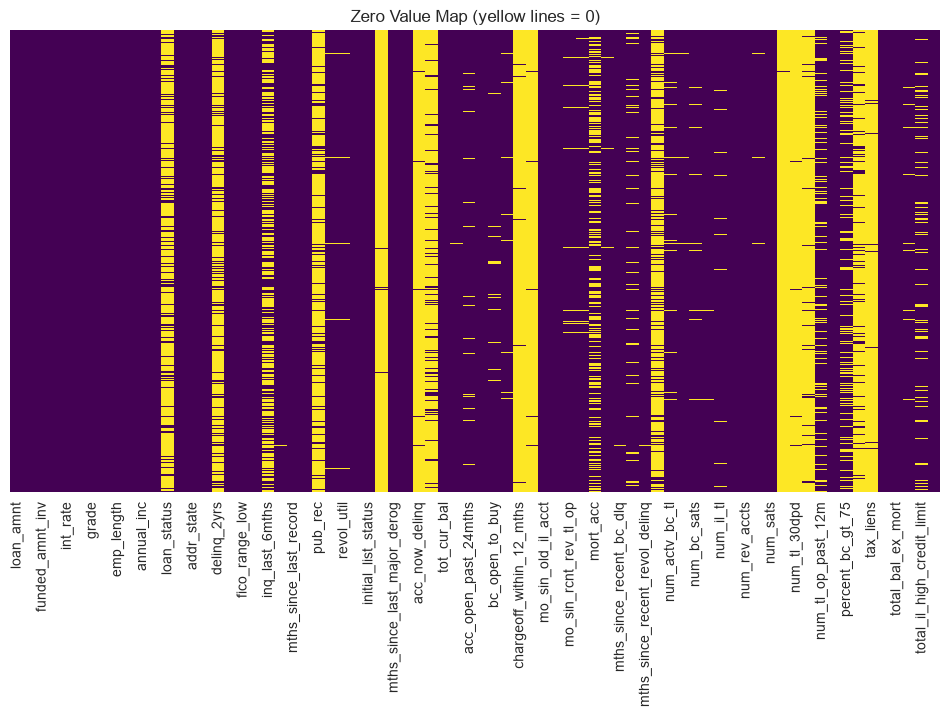

In [20]:
df_sample = df_accepted.sample(n=50000, random_state=42)
# Create a boolean DF where True means the value is 0
zero_matrix = (df_sample==0)
plt.figure(figsize=(12,6))
# Same heatmap as before but now yellow/bright=0, and purple/dark= non-zero
sns.heatmap(zero_matrix, cbar=False, yticklabels=False, cmap='viridis')
plt.title("Zero Value Map (yellow lines = 0)")
plt.show()

In [21]:
# (df==0) creates a True/False table and .mean() calculates the % of Trues 
zero_percentage = (df_accepted==0).mean()
# Create the list of columns that are potentially going to be dropped
cols_to_drop = zero_percentage[zero_percentage > 0.80].index.tolist()
keep_regardless = [
    'loan_status',
    'pub_rec',
    'pub_rec_bankruptcies', 
    'tax_liens',
    'acc_now_delinq',
    'delinq_2yrs',
    'chargeoff_within_12_mths',
    'collections_12_mths_ex_med'
]
cols_to_drop = [c for c in cols_to_drop if c not in keep_regardless]
print(f"Dropping {len(cols_to_drop)} columns that are mostly zero: \n{cols_to_drop}")
print(f"Keeping rare but critical signals: {keep_regardless[1:]}")
df_accepted = df_accepted.drop(columns=cols_to_drop)
print(f"\nFinal cleaned shape: {df_accepted.shape}")

Dropping 5 columns that are mostly zero: 
['tot_coll_amt', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m']
Keeping rare but critical signals: ['pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 'acc_now_delinq', 'delinq_2yrs', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med']

Final cleaned shape: (1345310, 69)


In [22]:
categorical_cols = df_accepted.select_dtypes(include=['string', 'object']).columns
for col in categorical_cols:
    unique_vals = df_accepted[col].nunique()
    print(f"column {col} has {unique_vals} unqiue vals")

df_accepted = df_accepted.drop(columns='addr_state')

column term has 2 unqiue vals
column grade has 7 unqiue vals
column sub_grade has 35 unqiue vals
column emp_length has 12 unqiue vals
column home_ownership has 6 unqiue vals
column verification_status has 3 unqiue vals
column purpose has 14 unqiue vals
column addr_state has 51 unqiue vals
column earliest_cr_line has 739 unqiue vals
column initial_list_status has 2 unqiue vals
column application_type has 2 unqiue vals
column disbursement_method has 2 unqiue vals


In [23]:
df_accepted[['term', 'emp_length']]

,term,emp_length
0,36 months,10+ years
1,36 months,10+ years
2,60 months,10+ years
4,60 months,3 years
5,36 months,4 years
...,...,...
2260688,60 months,5 years
2260690,60 months,9 years
2260691,60 months,3 years
2260692,60 months,10+ years


In [24]:
# clean 'term' column (remove text, keep number)
if not pd.api.types.is_numeric_dtype(df_accepted['term']):
    df_accepted['term'] = df_accepted['term'].str.replace(' months', '').str.strip().astype(int)
    print("Converted 'term' to integers (36, 60).")

# clean up "emp_length" (extract years): format is 10+years = 10, <1year=0, 3years=3
if not pd.api.types.is_numeric_dtype(df_accepted['emp_length']):
    emp_map = {
        '< 1 year': 0,
        '1 year': 1,
        '2 years': 2,
        '3 years': 3,
        '4 years': 4,
        '5 years': 5,
        '6 years': 6,
        '7 years': 7,
        '8 years': 8,
        '9 years': 9,
        '10+ years': 10,
        'Unknown': -1,
    }
    df_accepted['emp_length'] = df_accepted['emp_length'].map(emp_map)
    assert df_accepted['emp_length'].notna().all(), "unmapped emp_length category"
    df_accepted['emp_length'] = df_accepted['emp_length'].astype(int)
    print("Converted 'emp_length' to ordinal (-1 to 10).")

# convert date to years of history, datetime
df_accepted['earliest_cr_line'] = pd.to_datetime(df_accepted['earliest_cr_line'], format='%b-%Y')
# calc years relative to the most recent date in data
max_date = df_accepted['earliest_cr_line'].max()
df_accepted['credit_hist_years'] = (max_date - df_accepted['earliest_cr_line']).dt.days / 365.25
df_accepted = df_accepted.drop(columns=['earliest_cr_line'])

# map sub_grade (A1 -> 1, G5 -> 35)
grades = ['A', 'B', 'C', 'D', 'E', 'G']
sub_grades = [f"{g}{i}" for g in grades for i in range(1,6)]
sub_grade_map = {val: i+1 for i, val in enumerate(sub_grades)}
df_accepted['sub_grade'] = df_accepted['sub_grade'].map(sub_grade_map)
df_accepted['sub_grade'] = df_accepted['sub_grade'].fillna(df_accepted['sub_grade'].median())

# drop redundant grade
df_accepted = df_accepted.drop(columns=['grade'])

print(df_accepted[['term', 'emp_length', 'credit_hist_years', 'sub_grade']].head())

Converted 'term' to integers (36, 60).
Converted 'emp_length' to ordinal (-1 to 10).
   term  emp_length  credit_hist_years  sub_grade
0    36          10          12.167009       14.0
1    36          10          15.832991       11.0
2    60          10          15.164956        9.0
4    60           3          17.333333       11.0
5    36           4          28.000000       13.0


In [25]:
df_accepted.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,credit_hist_years
0,3600.0,3600.0,3600.0,36,13.99,123.03,14.0,10,MORTGAGE,55000.0,Not Verified,0,debt_consolidation,5.91,0.0,675.0,679.0,1.0,30.0,1000.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,Individual,0.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,12.167009
1,24700.0,24700.0,24700.0,36,11.99,820.28,11.0,10,MORTGAGE,65000.0,Not Verified,0,small_business,16.06,1.0,715.0,719.0,4.0,6.0,1000.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,1000.0,Individual,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,113.0,192.0,2.0,2.0,4.0,2.0,1000.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,15.832991
2,20000.0,20000.0,20000.0,60,10.78,432.66,9.0,10,MORTGAGE,63000.0,Not Verified,0,home_improvement,10.78,0.0,695.0,699.0,0.0,1000.0,1000.0,6.0,0.0,7869.0,56.2,18.0,w,0.0,1000.0,Joint App,0.0,189699.0,14000.0,6.0,31617.0,2737.0,55.9,0.0,125.0,184.0,14.0,14.0,5.0,101.0,1000.0,10.0,1000.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,15.164956
4,10400.0,10400.0,10400.0,60,22.45,289.91,11.0,3,MORTGAGE,104433.0,Source Verified,0,major_purchase,25.37,1.0,695.0,699.0,3.0,12.0,1000.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,1000.0,Individual,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,17.333333
5,11950.0,11950.0,11950.0,36,13.44,405.18,13.0,4,RENT,34000.0,Source Verified,0,debt_consolidation,10.20,0.0,690.0,694.0,0.0,1000.0,1000.0,5.0,0.0,8822.0,68.4,6.0,w,0.0,1000.0,Individual,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,1000.0,5.0,1000.0,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,28.000000


In [26]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols = df_accepted.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_df = df_accepted.select_dtypes(exclude=['object', 'string'])
print(f"Encoding {len(categorical_cols)} columns: {categorical_cols}")
# initalize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype='int8')
# fit and transform
encoded_array = encoder.fit_transform(df_accepted[categorical_cols])
# note get_features_names_out() automatically names the columns created as "home_ownership_rent", "purpose_medical", etc.
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_accepted.index
)
# merge (numeric + encoded)
df_final = pd.concat([numeric_df, encoded_df], axis=1)

print(f"Original Shape: {df_accepted.shape}")
print(f"Final Shape: {df_final.shape}")
print("-"*30)
print("New column examples:")
print(df_final.columns[-10:].tolist())

Encoding 6 columns: ['home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'disbursement_method']
Original Shape: (1345310, 67)
Final Shape: (1345310, 90)
------------------------------
New column examples:
['purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'initial_list_status_f', 'initial_list_status_w', 'application_type_Individual', 'application_type_Joint App', 'disbursement_method_Cash', 'disbursement_method_DirectPay']


-- Top 20 Strongest Predictors of Default --
int_rate                            0.258792
sub_grade                           0.247677
term                                0.176096
fico_range_low                      0.130683
fico_range_high                     0.130682
acc_open_past_24mths                0.099427
verification_status_Not Verified    0.086929
dti                                 0.084499
num_tl_op_past_12m                  0.084397
bc_open_to_buy                      0.078591
avg_cur_bal                         0.074760
tot_hi_cred_lim                     0.074505
mort_acc                            0.072468
num_actv_rev_tl                     0.070442
total_bc_limit                      0.069575
num_rev_tl_bal_gt_0                 0.069026
home_ownership_MORTGAGE             0.068199
tot_cur_bal                         0.067133
percent_bc_gt_75                    0.066326
home_ownership_RENT                 0.066086
dtype: float64


C:\Users\henry\AppData\Local\Temp\ipykernel_51612\3918190441.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='coolwarm')


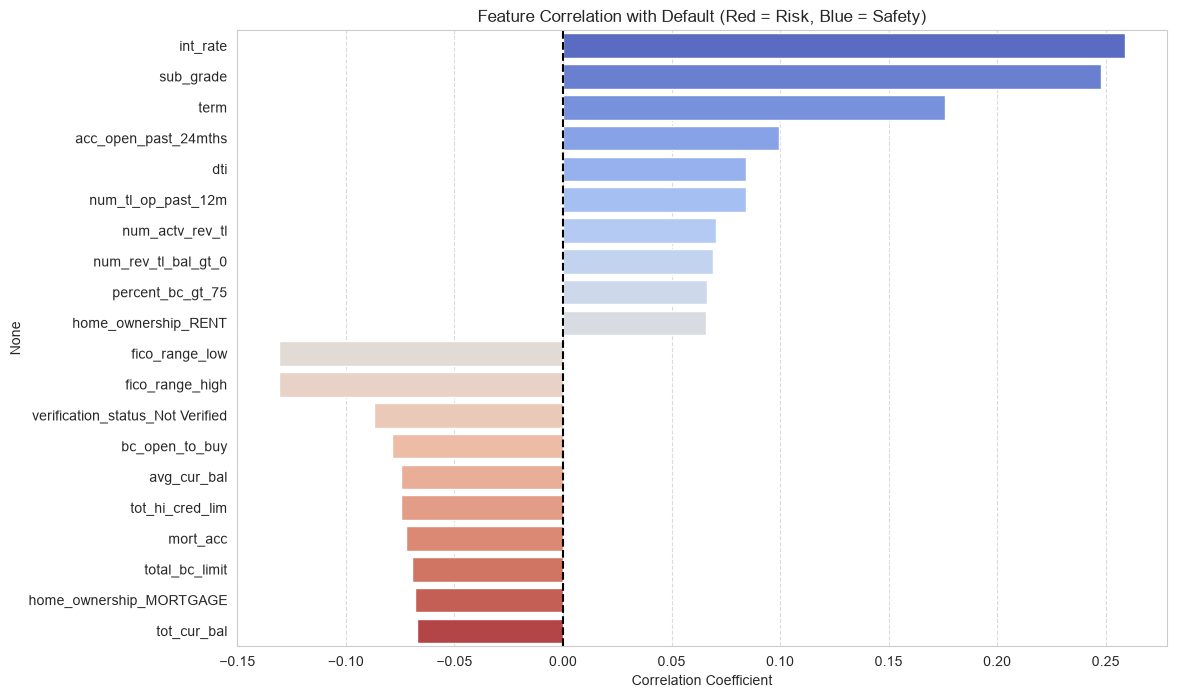

In [27]:
# Calculate correlation of ALL columns against 'loan_status' instantly
all_corrs = df_final.corrwith(df_final['loan_status'])
# Sort by strength
correlation_leaderboard = all_corrs.drop('loan_status').abs().sort_values(ascending=False)
print("-- Top 20 Strongest Predictors of Default --")
print(correlation_leaderboard.head(20))
# plot of the top 10 positive (risk factors) and top 10 negative (safety factors) features
top_positive = all_corrs.drop('loan_status').nlargest(10)
top_negative = all_corrs.drop('loan_status').nsmallest(10)
top_20 = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12,8))
sns.barplot(x=top_20.values, y=top_20.index, palette='coolwarm')
plt.title('Feature Correlation with Default (Red = Risk, Blue = Safety)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [28]:
# Create some useful features
# 1 Laon-to-Income Ratio (How heavy is this specific laon?)
df_final['loan_to_income'] = df_final['loan_amnt'] / (df_final['annual_inc'] + 1)

# 2 Average Credit Limit (Are they trusted with big cards or small cards?)
# Use 'total_bc_limit' (Bankcard limit) and 'num_bc_tl' (Number of bankcard accounts)
df_final['avg_card_limit'] = np.where(
    df_final['num_bc_tl'] > 0,
    df_final['total_bc_limit'] / df_final['num_bc_tl'],
    0
)
# 3 Credit Utilization Gap (Available Credit / Total Limit)
df_final['available_credit_ratio'] = np.where(
    df_final['total_bc_limit'] > 0,
    df_final['bc_open_to_buy'] / df_final['total_bc_limit'],
    0
)
# 4 Monthly Burden (installment-to-monthly-income)
monthly_income=df_final['annual_inc'] / 12
df_final['installment_to_income'] = df_final['installment'] / (monthly_income + 1)

# 5 Credit Velocity (new account per year)
df_final['credit_velocity'] = df_final['total_acc'] / (df_final['credit_hist_years'] + 1)

# 6 Account survival ratio (stability)
df_final['account_survival'] = df_final['open_acc'] / (df_final['total_acc'] + 1)

# check correlations of new features created
new_features = [
    'loan_to_income', 'avg_card_limit', 'available_credit_ratio',
    'installment_to_income', 'credit_velocity', 'account_survival'
]
print(df_final[new_features].join(df_final['loan_status']).corr()['loan_status'].sort_values())

avg_card_limit           -0.070401
available_credit_ratio   -0.062881
loan_to_income            0.000535
installment_to_income     0.001092
credit_velocity           0.032804
account_survival          0.057991
loan_status               1.000000
Name: loan_status, dtype: float64


In [29]:
# domian knowledge say they matter
safe_list = [
    'loan_to_income', 
    'installment_to_income', 
    'tax_liens', 
    'pub_rec', 
    'pub_rec_bankruptcies', 
    'chargeoff_within_12_mths',
    'acc_now_delinq',
    'loan_amnt'
]
# remove noise features (low correlation)
target_corr = df_final.corrwith(df_final['loan_status']).abs()
# find columsn with corr < 0.01 (to weak to be useful)
noise_candidates = target_corr[target_corr < 0.01].index.tolist()
to_drop_noise = [col for col in noise_candidates if col not in safe_list]
if 'loan_status' in to_drop_noise:
    to_drop_noise.remove('loan_status')
print(f"Weak features (<0.01): {to_drop_noise}, there are {len(to_drop_noise)}")
df_final = df_final.drop(columns=to_drop_noise)
# create a correlation matrix of the feature (ignoring the target)
corr_matrix = df_final.drop(columns=['loan_status']).corr().abs()
# corr matrices are symmetrical, so we only need to look at the "upper triangle" of matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_redundant = []
for col in upper.columns:
    # get list of duplicates for this column
    duplicates = upper.index[upper[col] > 0.95].tolist()
    for dup in duplicates:
        # compare target correlation: 'col' is candidate to drop, unless 'dup' is worse
        if target_corr.get(col, 0) < target_corr.get(dup, 0):
            candidate = col
            alternate = dup
        else:
            candidate = dup
            alternate = col
        # save any columns that are in the 'safe_list'
        if candidate in safe_list:
            if alternate not in safe_list:
                to_drop_redundant.append(alternate)
            else:
                pass
        else:
            to_drop_redundant.append(candidate)
            
# find columns with corr > 0.95
to_drop_redundant = list(set(to_drop_redundant))
print(f"redunant features (>0.95): {to_drop_redundant}, there are {len(to_drop_redundant)}")

df_final= df_final.drop(columns=to_drop_redundant)
print(f"Final Feature Count: {df_final.shape}")

Weak features (<0.01): ['num_il_tl', 'num_rev_accts', 'total_bal_ex_mort', 'total_il_high_credit_limit', 'home_ownership_ANY', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'purpose_educational', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_vacation', 'purpose_wedding', 'initial_list_status_f', 'initial_list_status_w', 'disbursement_method_Cash', 'disbursement_method_DirectPay'], there are 21
redunant features (>0.95): ['installment', 'tot_cur_bal', 'funded_amnt_inv', 'available_credit_ratio', 'num_rev_tl_bal_gt_0', 'fico_range_high', 'num_sats', 'application_type_Individual', 'funded_amnt'], there are 9
Final Feature Count: (1345310, 66)


In [30]:
# keep bank-specific features to seperate (Evaluation Data)
bank_cols = ['sub_grade', 'int_rate', 'loan_amnt']
bank_info = df_final[bank_cols].copy()
# drop them to prevent the model from relying on the bank's data (somewhat of a cheat sheet, since the bank doesn't know these things before they're on the balance sheet)
df_final = df_final.drop(columns=bank_cols)
print(f"Bank Info Shape: {bank_info.shape}")
print(f"Training Data Shape: {df_final.shape}")

Bank Info Shape: (1345310, 3)
Training Data Shape: (1345310, 63)


In [31]:
# define features (x) and target (y)
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']
print(f"Original Shape: {X.shape}")

# align origination dates back to the final feature frame
dates = issue_dates.reindex(df_final.index)
assert dates.notna().all(), "dates lost rows upstream"

# --- OUT-OF-TIME SPLIT: train on pre-2017 originations, test on 2017-2018 ---
CUTOFF = pd.Timestamp("2017-01-01")
train_mask = dates < CUTOFF
test_mask = dates >= CUTOFF

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
bank_train, bank_test = bank_info[train_mask], bank_info[test_mask]

print(f"Train: {dates[train_mask].min().date()} -> {dates[train_mask].max().date()}  n={len(X_train):,}")
print(f"Test:  {dates[test_mask].min().date()} -> {dates[test_mask].max().date()}  n={len(X_test):,}")
print(f"Default rate — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

# NOTE: undersampling removed (validation finding: discarded 61% of training data
# and, stacked with scale_pos_weight, inflated mean predicted PD to ~3.2x actual)

Original Shape: (1345310, 62)
Train: 2007-06-01 -> 2016-12-01  n=1,119,699
Test:  2017-01-01 -> 2018-12-01  n=225,611
Default rate — train: 0.1970 | test: 0.2128


In [32]:
# Approximatley 30 seconds to run cell
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

# train scout models
# scout A: Random Forest (stability / gini impurity)
rf_scout = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=12
)
rf_scout.fit(X_train, y_train)
print("Random Forest Scout Done")

# scout B: XGBoost (Performance / information gain)
xgb_scout = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_scout.fit(X_train, y_train)
print("XGBoost Scout done.")

# build the leaderboards
feature_ranks = pd.DataFrame({
    'Feature': X_train.columns,
    'Gini_score': rf_scout.feature_importances_,
    'Gain_score': xgb_scout.feature_importances_
})
# seclect top 35 for each method
top_30_gini = feature_ranks.nlargest(30, 'Gini_score')['Feature'].tolist()
top_30_gain = feature_ranks.nlargest(30, 'Gain_score')['Feature'].tolist()
# remove duplicates
final_features = sorted(set(top_30_gini + top_30_gain))

print(f"\n -------- Feature Selection Results ---------")
print(f"RF (Gini) selected: {len(top_30_gini)}")
print(f"XGB (Gain) selected: {len(top_30_gain)}")
print(f"Unique union cout: {len(final_features)}")
print(f"The choose ones: {final_features}")

#filter data
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

Random Forest Scout Done
XGBoost Scout done.

 -------- Feature Selection Results ---------
RF (Gini) selected: 30
XGB (Gain) selected: 30
Unique union cout: 39
The choose ones: ['acc_open_past_24mths', 'account_survival', 'annual_inc', 'avg_card_limit', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'credit_hist_years', 'credit_velocity', 'delinq_2yrs', 'dti', 'emp_length', 'fico_range_low', 'home_ownership_MORTGAGE', 'home_ownership_RENT', 'inq_last_6mths', 'installment_to_income', 'loan_to_income', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_actv_rev_tl', 'num_tl_op_past_12m', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_small_business', 'revol_bal', 'revol_util', 'term', 'tot_hi_cred_lim', 'total_acc', 'total_bc_limit', 'total_rev_hi_lim', 'verification_status_Not Verified']


In [33]:
# Approximately 45-75 minutes on CPU (full 1.12M-row training set)
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

param_grid = {
    'n_estimators': [200, 500, 800, 1000],
    'max_depth': [3, 4, 5, 6, 7],
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'min_child_weight': [1, 5, 10, 20, 50],
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9],
    'scale_pos_weight': [1],   # pinned: validation finding — stacked imbalance corrections destroyed calibration
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 10, 50]
}

n_iter = 50
params_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
best_score = 0
best_params = None
print(f"Starting Manual Hyperparameter Tuning ({n_iter} runs)...")

for i, params in enumerate(params_list):
    fold_scores = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # 5-fold CV within the training window
    for train_idx, val_idx in kf.split(X_train_final, y_train):
        X_fold_train = X_train_final.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train_final.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = xgb.XGBClassifier(
            **params,
            objective='binary:logistic',
            eval_metric='auc',
            device='cpu',
            tree_method='hist',
            n_jobs=-1,
            random_state=42
        )
        model.fit(X_fold_train, y_fold_train, verbose=False)
        preds = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(roc_auc_score(y_fold_val, preds))

    avg_score = np.mean(fold_scores)
    if (i+1) % 5 == 0:
        print(f"Iter {i+1}/{n_iter} | CV AUC: {avg_score:.4f}")
    if avg_score > best_score:
        best_score = avg_score
        best_params = params

print(f"\nBest CV AUC (training window): {best_score:.4f}")
print(f"Best Params: {best_params}")

print(f"\nTraining final model with best parameters...")
final_model = xgb.XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='auc',
    device='cpu',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_train_final, y_train)

# --- OOT TEST EVALUATION (the numbers that matter) ---
y_probs_test = final_model.predict_proba(X_test_final)[:, 1]
print(f"\nOOT Test AUC: {roc_auc_score(y_test, y_probs_test):.4f}")
print(f"Mean predicted PD: {y_probs_test.mean():.4f} | Actual default rate: {y_test.mean():.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, (y_probs_test >= 0.5).astype(int)).ravel()
print(f"\nAt threshold 0.5 — TP: {tp} | FN: {fn} | FP: {fp}")
print(classification_report(y_test, (y_probs_test >= 0.5).astype(int)))

Starting Manual Hyperparameter Tuning (50 runs)...
Iter 5/50 | CV AUC: 0.7285
Iter 10/50 | CV AUC: 0.7285
Iter 15/50 | CV AUC: 0.7194
Iter 20/50 | CV AUC: 0.7199
Iter 25/50 | CV AUC: 0.7244
Iter 30/50 | CV AUC: 0.7210
Iter 35/50 | CV AUC: 0.7285
Iter 40/50 | CV AUC: 0.7247
Iter 45/50 | CV AUC: 0.7211
Iter 50/50 | CV AUC: 0.7268

Best CV AUC (training window): 0.7285
Best Params: {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1000, 'min_child_weight': 50, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 0.6}

Training final model with best parameters...

OOT Test AUC: 0.7181
Mean predicted PD: 0.2259 | Actual default rate: 0.2128

At threshold 0.5 — TP: 7335 | FN: 40680 | FP: 6990
              precision    recall  f1-score   support

           0       0.81      0.96      0.88    177596
           1       0.51      0.15      0.24     48015

    accuracy                           0.79    225611
   macro avg       0.66    

In [34]:
y_probs_test = final_model.predict_proba(X_test_final)[:, 1]
print(f"OOT Test AUC: {roc_auc_score(y_test, y_probs_test):.4f}")
print(f"Mean predicted PD: {y_probs_test.mean():.4f} | Actual default rate: {y_test.mean():.4f}")

OOT Test AUC: 0.7181
Mean predicted PD: 0.2259 | Actual default rate: 0.2128


In [35]:
# Get the probabilities (the % chance of default for each person)
y_probs = final_model.predict_proba(X_test_final)[:, 1]
# define the thresholds to test, go from 0.5 (standard) down to 0.2 (paranoia)
thresholds = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25]
print(f"{'Threshold':<10} | {'Defaults Caught (TP)':<20} | {'Defaults Missed (FN)':<20} | {'Good Loans Rejected (FP)':<22}")
print("-"*85)
for t in thresholds:
    # apply new threshold
    y_pred_new = (y_probs >=t).astype(int)
    # new confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_new).ravel()
    print(f"{t:<10} | {tp:<20} | {fn:<20} | {fp:22}")

Threshold  | Defaults Caught (TP) | Defaults Missed (FN) | Good Loans Rejected (FP)
-------------------------------------------------------------------------------------
0.5        | 7335                 | 40680                |                   6990
0.45       | 10389                | 37626                |                  11250
0.4        | 14071                | 33944                |                  17238
0.35       | 18374                | 29641                |                  25658
0.3        | 23626                | 24389                |                  37314
0.25       | 29198                | 18817                |                  53072


In [36]:
X_test.head()

,term,emp_length,annual_inc,dti,delinq_2yrs,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_op_rev_tl,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bc_limit,credit_hist_years,home_ownership_MORTGAGE,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_small_business,application_type_Joint App,loan_to_income,avg_card_limit,installment_to_income,credit_velocity,account_survival
421101,36,9,52000.0,0.58,0.0,760.0,0.0,26.0,1000.0,7.0,0.0,141.0,0.5,30.0,0.0,1000.0,0.0,31000.0,3.0,25099.0,30359.0,0.5,0.0,132.0,242.0,18.0,7.0,4.0,18.0,1000.0,7.0,1000.0,0.0,1.0,1.0,4.0,15.0,6.0,1.0,96.7,0.0,0.0,0.0,191216.0,30500.0,17.746749,0,1,0,1,0,0,0,0,0,0,0,0.057691,2033.333333,0.021480,1.600277,0.225806
421113,36,10,55000.0,14.18,0.0,675.0,0.0,74.0,82.0,14.0,1.0,11449.0,33.9,24.0,0.0,74.0,0.0,33800.0,2.0,2222.0,10551.0,52.0,0.0,77.0,199.0,3.0,3.0,0.0,3.0,1000.0,12.0,1000.0,1.0,3.0,3.0,4.0,7.0,13.0,2.0,95.7,33.3,1.0,0.0,61551.0,22000.0,14.165640,0,0,1,0,0,0,0,0,0,0,0,0.090907,3142.857143,0.036217,1.582525,0.560000
421120,36,0,40000.0,20.25,0.0,695.0,0.0,60.0,1000.0,13.0,0.0,5004.0,36.0,29.0,0.0,60.0,0.0,13900.0,4.0,10977.0,4996.0,50.0,0.0,122.0,132.0,1.0,1.0,0.0,10.0,64.0,5.0,60.0,3.0,2.0,2.0,3.0,4.0,7.0,2.0,89.7,33.3,0.0,0.0,132817.0,10000.0,8.585900,1,0,0,0,1,0,0,0,1,0,0,0.174996,2500.000000,0.069711,3.025277,0.433333
421135,36,10,57000.0,27.58,0.0,680.0,1.0,68.0,1000.0,11.0,0.0,29222.0,53.2,26.0,0.0,68.0,0.0,55500.0,5.0,14324.0,19752.0,33.5,0.0,195.0,215.0,11.0,6.0,2.0,11.0,1000.0,0.0,1000.0,1.0,3.0,4.0,6.0,7.0,9.0,5.0,96.0,33.3,0.0,0.0,188780.0,29400.0,15.498973,0,0,0,0,1,0,0,1,0,0,0,0.526307,4200.000000,0.240663,1.575856,0.407407
421137,60,10,85000.0,15.76,1.0,665.0,0.0,2.0,1000.0,15.0,0.0,14591.0,34.2,27.0,0.0,1000.0,0.0,42700.0,8.0,8551.0,16684.0,38.4,0.0,67.0,112.0,4.0,4.0,3.0,4.0,1000.0,0.0,2.0,0.0,5.0,7.0,6.0,10.0,12.0,4.0,92.6,16.7,0.0,0.0,172433.0,27100.0,6.913073,0,0,0,1,0,0,0,0,0,0,0,0.247056,2710.000000,0.079180,3.412075,0.535714


In [ ]:
# 1. Market Inputs (2026 Scneario)
risk_free_3y = 0.0357   # 3.57% (3y Treasury)
risk_free_5y = 0.0375   # 3.75% (5y Treasury)
bank_spread = 0.0150    # 1.50% (cost of operations)

cost_36m = risk_free_3y + bank_spread
cost_60m = risk_free_5y + bank_spread

print(f"----2026 Market Enviroment (snapshot) ----")
print(f"Hurdle Rate (36m): {cost_36m:.2%}")
print(f"Hurdle Rate (60m): {cost_60m:.2%}")

# 2. Prepare Financial Data (saved using bank_info df)
loan_amnt = bank_test['loan_amnt'].values
int_rate = bank_test['int_rate'].values
term = X_test['term'].values

# fix interest rates (ensure 15.5% becomes 0.155)
int_rate = np.where(int_rate > 1, int_rate / 100, int_rate)

# determine cost of funds per loan
is_long_term = (term == 60) | (term == '60 months')
loan_cost = np.where(is_long_term, cost_60m, cost_36m)
duration_years = np.where(is_long_term, 5, 3)

# 3. Calculate Potential Outcomes
# Scneario A: they pay (profit = interest income - cost of funds)
profit_if_paid = loan_amnt * (int_rate - loan_cost) * duration_years

# Scenario B: they default (loss = principal * (1 - Recovery Rate)), assume 10% recovery rate to mimic industry standard
loss_if_default = -loan_amnt * (1 - 0.10)

# storage for the table

# 4. Run the Optimization loop
thresholds = np.linspace(0.20, 1.00, 81)
net_profits = []
results_data = []

y_probs = final_model.predict_proba(X_test_final)[:, 1]
y_true = y_test.values if hasattr(y_test, 'values') else y_test

best_threshold = 0
max_profit = -float('inf')

print(f"\n{'Threshod':<10} | {'Net Profit':<20} | {'Defaults Avoided':<20}")
print("-"*60)

for t in thresholds:
    # decision: Approve if probability of default < threshold
    approve_mask = (y_probs < t)
    # sum profit/loss only for the loans we approve
    # Good laons we approved (we make profit)
    profit_realized = np.sum(profit_if_paid[approve_mask & (y_true==0)])
    # Bad loans we approved (wek take loss)
    loss_realized = np.sum(loss_if_default[approve_mask & (y_true==1)])
    # net P&L
    total_net = profit_realized + loss_realized
    net_profits.append(total_net)
    # track winner
    if total_net > max_profit:
        max_profit = total_net
        best_threshold = t

    # Capture data for the README table (at 5% increments)
    if round(t * 100) % 5 == 0:
        defaults_avoided = np.sum((y_probs >= t) & (y_true == 1))
        results_data.append({
            "Approval Threshold": f"{t:.2f}",
            "Net Profit ($M)": f"${total_net/1_000_000:.2f}M",
            "Defaults Avoided": int(defaults_avoided)
        })

# baseline: approve every applicant (no model)  ← column 0, loop is finished
baseline_profit = np.sum(profit_if_paid[y_true == 0]) + np.sum(loss_if_default[y_true == 1])
print(f"\nApprove-everyone baseline: ${baseline_profit/1_000_000:.2f}M")
print(f"Model at optimal threshold {best_threshold:.2f}: ${max_profit/1_000_000:.2f}M")
print(f"INCREMENTAL model value: ${(max_profit - baseline_profit)/1_000_000:.2f}M")

profit_table = pd.DataFrame(results_data).to_string(index=False)
print(profit_table)
print(f"-----------------------------------------------------------------\n")

# 5. Visualize Profit Curve
plt.figure(figsize=(10,6))
plt.plot(thresholds, [p/1_000_000 for p in net_profits], color='#2E8B57', linewidth=3)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal: {best_threshold:.2f}')
plt.title('Net Portfolio Profit vs Approval Threshold')
plt.xlabel('Approval Threshold (Strict <---------> Loose)')
plt.ylabel('Net Profit (Millions $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('profit_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph saved as 'profit_optimization.png'")
print(f"\nFinal Recommendation:")
print(f"Optimal Threshold: {best_threshold:.2%}")
print(f"Projected Profit: ${max_profit/1_000_000:.2f} Million")

----2026 Market Enviroment (snapshot) ----
Hurdle Rate (36m): 5.07%
Hurdle Rate (60m): 5.25%

Threshod   | Net Profit           | Defaults Avoided    
------------------------------------------------------------


ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

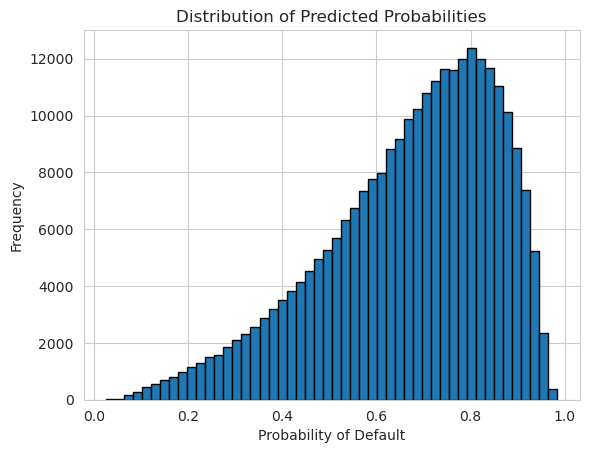

Mean Probability: 0.6704


In [ ]:
import matplotlib.pyplot as plt

# Check the distribution of probabilities
plt.hist(y_probs, bins=50, edgecolor='k')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability of Default")
plt.ylabel("Frequency")
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the mean probability
print(f"Mean Probability: {y_probs.mean():.4f}")

In [ ]:
import json
import os

print(f"----- Saving Default Risk Model & Features (production ready) ----")
# 'models' folder path
folder_path = 'Models'
os.makedirs(folder_path, exist_ok=True)
model_path = os.path.join(folder_path, 'default_risk_model_v1.json')
features_path = os.path.join(folder_path, 'default_model_features.json')

# save the model (xgboost specific format)
final_model.save_model(model_path)
print(f"Model saved succesfully to: {model_path}")
# save feature list
feature_list = X_test_final.columns.tolist()

with open(features_path, "w") as f:
    json.dump(feature_list, f)
    
print(f"Feature list ({len(feature_list)} features) saved safely to: {features_path}")

----- Saving Default Risk Model & Features (production ready) ----
Model saved succesfully to: Models/default_risk_model_v1.json
Feature list (41 features) saved safely to: Models/default_model_features.json
